In [4]:
%pip install pandas

  Using cached pandas-3.0.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached pandas-3.0.6-cp314-cp314-macosx_11_0_arm64.whl (10.2 MB)
Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl (5.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install requests
%pip install matplotlib




[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (125 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl (283 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.65.0-cp314-cp314-macosx_10_15_universal2.whl (3

In [7]:
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("kdramas_2023.csv")

df = df.sort_values("Popularity")
top20 = df.head(20)
top20 = top20[top20["Title_English"] != "Bloodhounds (2023)"]

wiki_titles = []
for t in top20["Title_English"]:
    t = t.replace(" (2023)", "")
    if t== "The Glory Part 2":
        t= "The Glory (TV series)"
    if t== "Moving":
        t= "Moving (South Korean TV series)"
    if t== "Celebrity":
        t= "Celebrity (South Korean TV series)"
    if t== "Love to Hate You":
        t= "Love to Hate You (TV series)"
    wiki_titles.append(t)

print(wiki_titles)

['Twinkling Watermelon', 'My Demon', 'King the Land', 'The Glory (TV series)', 'Moving (South Korean TV series)', "Death's Game", 'Welcome to Samdal-ri', 'See You in My 19th Life', 'Destined with You', 'The Good Bad Mother', 'My Lovely Liar', 'Crash Course in Romance', 'Love to Hate You (TV series)', 'Perfect Marriage Revenge', 'A Time Called You', 'Doona!', 'Celebrity (South Korean TV series)', 'Daily Dose of Sunshine', 'Gyeongseong Creature']


In [9]:
headers = {"User-Agent": "kdrama project (your_email@school.edu)"}
all_data=[]
for title in wiki_titles:
    page = title.replace(" ", "_")
    url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/" + page + "/daily/20220601/20240601"
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        items = response.json()["items"]
        data = pd.DataFrame(items)
        data["date"] = pd.to_datetime(data["timestamp"].str[:8])
        data["title"] = title
        all_data.append(data)
    else:
        print("didn't work for", title)
    time.sleep(1)
views = pd.concat(all_data, ignore_index=True)
views.to_csv("kdrama_pageviews.csv", index=False)

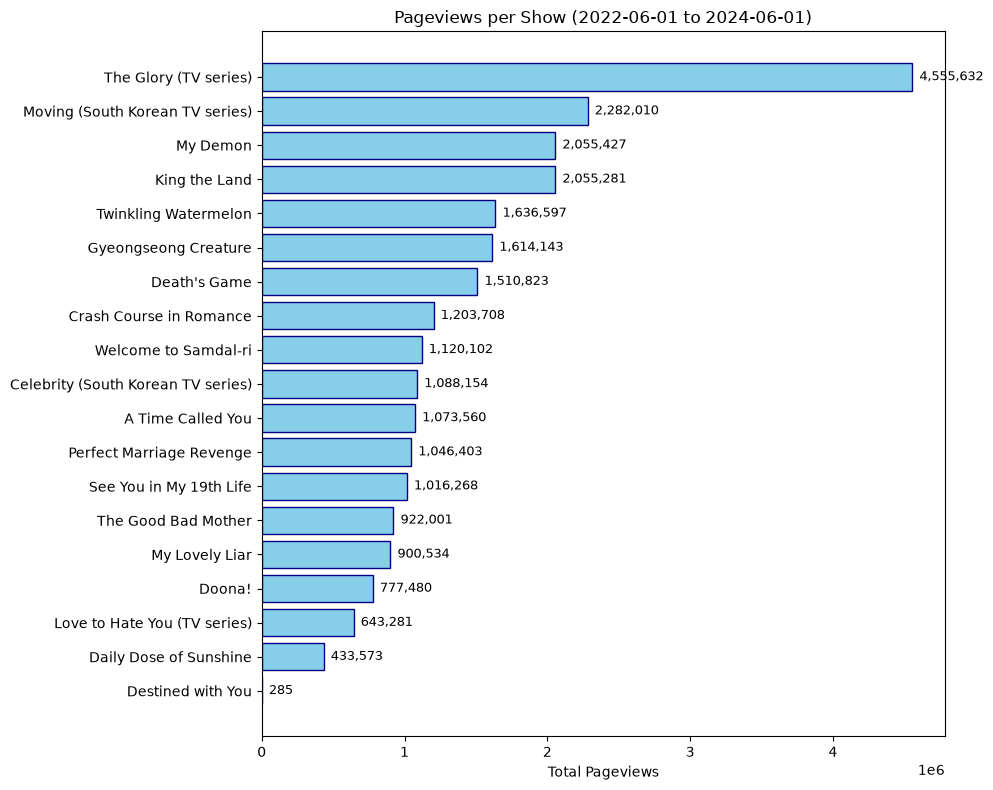

In [ ]:
#graph 1: total pageviews
totals = views.groupby("title")["views"].sum()
totals = totals.sort_values()

plt.figure(figsize=(10, 8))
plt.barh(totals.index, totals.values, color="skyblue", edgecolor="navy")
for i in range(len(totals)):
    plt.text(totals.values[i] + 50000, i, f"{totals.values[i]:,}", va="center", fontsize=9)
plt.xlabel("Total Pageviews")
plt.title("Pageviews per Show (2022-06-01 to 2024-06-01)")
plt.tight_layout()
plt.show()

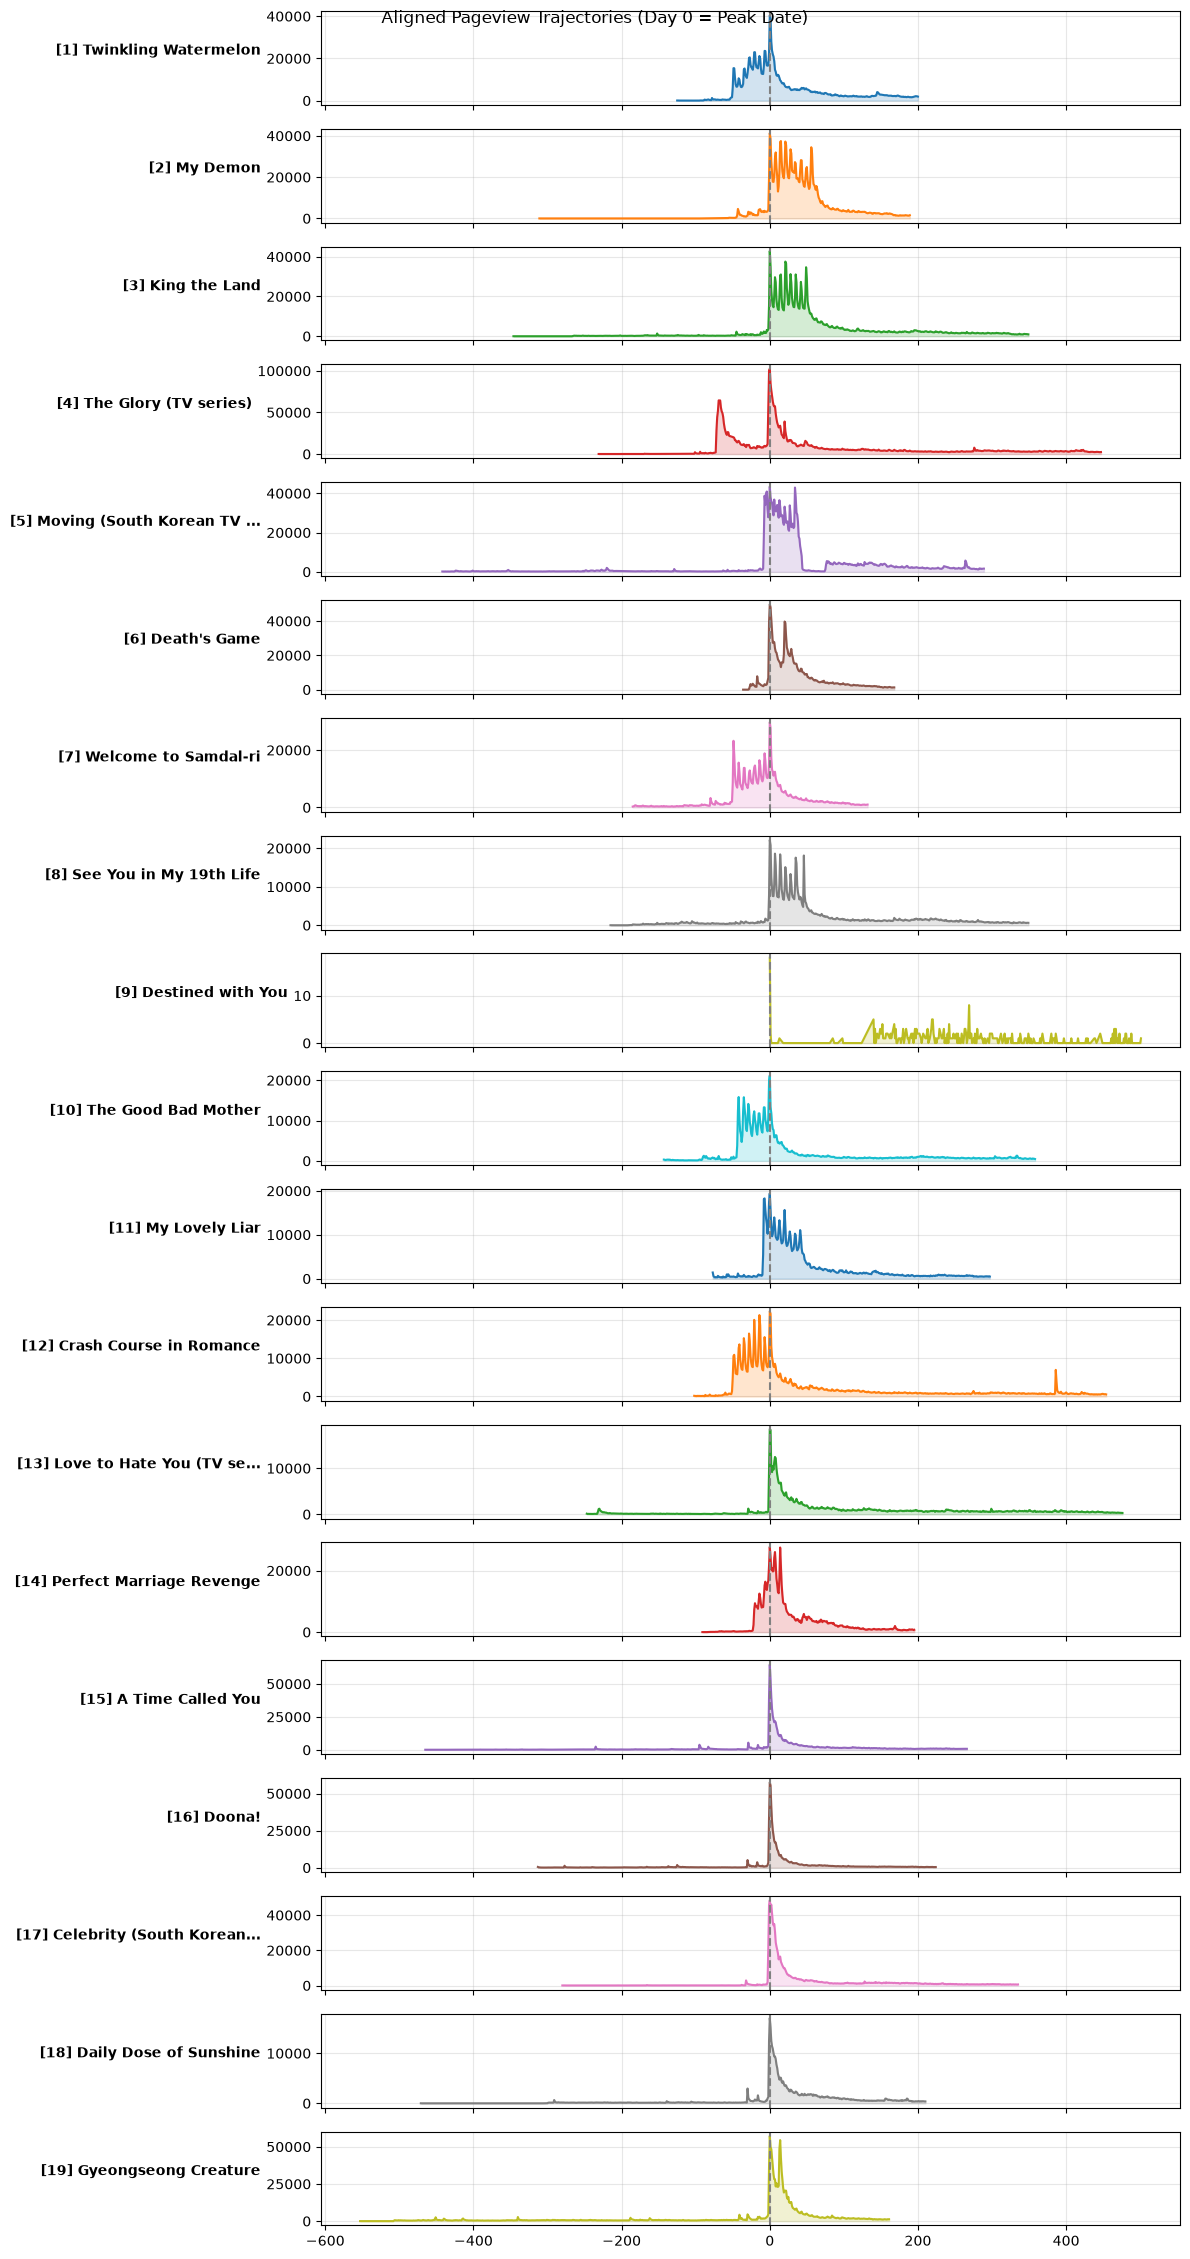

In [ ]:
#graph 2:pageviews lined up by peak day
fig,axes = plt.subplots(len(wiki_titles), 1, figsize=(12, 23), sharex=True)
colors = plt.cm.tab10.colors
for i in range(len(wiki_titles)):
    title=wiki_titles[i]
    ax=axes[i]
    show = views[views["title"] == title]
    peak_row= show["views"].idxmax()
    peak_date=show.loc[peak_row, "date"]
    days= (show["date"] - peak_date).dt.days
    color= colors[i % 10]
    ax.plot(days, show["views"], color=color)
    ax.fill_between(days, show["views"], color=color, alpha=0.2)
    ax.axvline(0, color="gray", linestyle="--")
    ax.grid(alpha=0.3)
    name = "[" + str(i + 1) + "] " + title
    if len(name) > 30:
        name = name[:28] + "..."
    ax.set_ylabel(name, rotation=0, ha="right", fontweight="bold")
plt.suptitle("Aligned Pageview Trajectories (Day 0 = Peak Date)")
plt.tight_layout()
plt.show()